In [1]:
using CMPSExcitations

In [53]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E / sqrt(2) - M * Diagonal(F) / M
        W2 = E / sqrt(2) + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q)
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

function leftcanonical(state, cmps=false)
    leftgauge!(state)
    r = rightenv(state)[1][]
    D, U = eigen(r)
    Q = U \ state.Q[] * U
    R = U \ state.Rs[1][] * U
    return (cmps) ? InfiniteCMPS(Constant(Q), (Constant(R), Constant(R))) : (Q, R)
end

leftcanonical (generic function with 2 methods)

In [59]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

# why does this work better???
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      c * (ψ̂₂') * (ψ̂₁') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

In [60]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [4]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("-------------------------------------")
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
leftgauge!(stateCLL)
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])
println("-------------------------------------")

Optimizing D=4
D = 4 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  0.055017 seconds (356.82 k allocations: 16.923 MiB)
---------------
Energy density: -2.7347478175232065
 Particle density: 0.4324435948703916
 Order parameter: 0.4386898377561108
-------------------------------------
Energy density: -2.734747817523222
Particle density: 0.8648871897407864
Density imbalance: 0.0
-------------------------------------


┌ Info: YangGaudinCMPS ground state: initialization with e = 88.019328209394
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 94 iterations: f = -2.734747817523, ‖∇f‖ = 4.9717e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 95 iterations: e = -2.734747817523, ‖∇e‖ = 4.9717e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


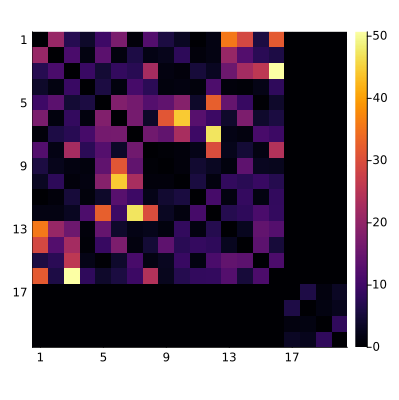

In [61]:
# stateCLL = leftcanonical(stateCLL, true)
_, M = eigen(stateLL.Rs[1][]);
P = projection_matrix(D, M)

Q = P[1:D^2, D^2+1:end]
Qn = Matrix(qr(Q).Q)
Pn = copy(P)
Pn[1:D^2, D^2+1:end] .= Qn / sqrt(2)
Pn[D^2+1:end, D^2+1:end] .= -Qn / sqrt(2)
Pn = Matrix(qr(P).Q);

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);
res = round.(Pn' * Heff * Pn, digits=1)

heatmap(abs.(res .- Diagonal(res)), yflip=true, aspect_ratio=1, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D)

In [30]:
ρ = real(expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[]);
ps = range(0, 2π * ρ, 16)

spectrum_even = zeros(length(ps), D^2)
spectrum_odd = zeros(length(ps), D)
Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff = excitation_matrix(excitation_operator(HCLL, space), D)
    res = round.(Pn' * Heff * Pn, digits=1)

    spectrum_even[idx, :] .= real.(eigen(res[1:D^2, 1:D^2]).values)
    spectrum_odd[idx, :] .= real.(eigen(res[D^2+1:end, D^2+1:end]).values)
end

### Explicitly constructing goldstone modes

In [46]:
function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

Q, R = stateCLL.Q[], stateCLL.Rs[1][];
ρR = rightenv(stateCLL)[1][];

pgs = range(0, 5., 20)
energies = zeros(ComplexF64, length(pgs))
ρR = rightenv(stateCLL)[1][];

Threads.@threads for idx in eachindex(pgs)
    V, W1, W2 = zero(Q), R, -R
    V, W1, W2 = leftgaugetv(Q, R, V, W1, W2, pgs[idx])

    # ∫⟨H⟩ - ⟨H₀⟩ = E -> intensive contribution to energy on top of extensive ground state energy
    space = InfiniteCMPSExcitationSpace(pgs[idx], stateCLL, stateCLL)
    Heff = excitation_operator(HCLL, space)
    P = projection_matrix(D, eigen(R).vectors)
    Hm = excitation_matrix(Heff, D)

    res = P * P' * Hm * P * P' * vcat(vec(W1), vec(W2))
    HW1f = reshape(view(res, 1:D^2), D, D)
    HW2f = reshape(view(res, D^2+1:2*D^2), D, D)

    energies[idx] = tr(HW1f * ρR * W1' + HW2f * ρR * W2') / tr(W1 * ρR * W1' + W2 * ρR * W2')
end

energies

20-element Vector{ComplexF64}:
 23.550932326189933 + 1.7297608186675235e-14im
 23.620184403752308 - 0.29652178188830175im
 23.827940636439237 - 0.5930435637766083im
 24.174201024250905 - 0.8895653456649094im
 24.658965567187156 - 1.186087127553233im
 25.282234265248118 - 1.4826089094415364im
 26.044007118433715 - 1.77913069132985im
 26.944284126743987 - 2.075652473218157im
 27.983065290178896 - 2.3721742551064677im
 29.160350608738423 - 2.6686960369947728im
 30.476140082422624 - 2.9652178188830787im
  31.93043371123148 - 3.2617396007713917im
  33.52323149516499 - 3.5582613826597074im
  35.25453343422316 - 3.85478316454801im
 37.124339528405955 - 4.151304946436317im
  39.13264977771345 - 4.447826728324622im
  41.27946418214556 - 4.744348510212941im
  43.56478274170233 - 5.040870292101242im
  45.98860545638384 - 5.337392073989551im
   48.5509323261899 - 5.633913855877861im

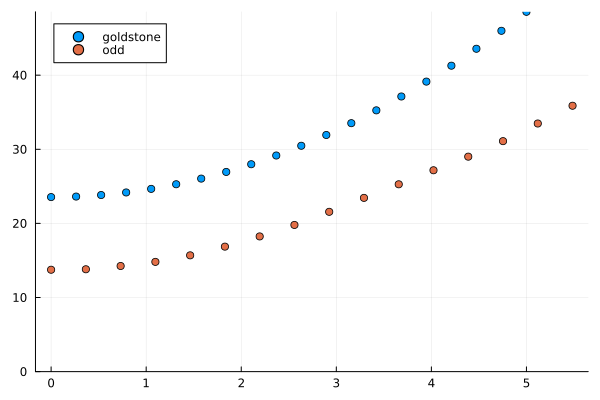

In [47]:
scatter(pgs, real.(energies), lab="goldstone")
scatter!(ps, spectrum_odd[:, 1], lab="odd", ylim=[0, Inf])